[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pushkar0997/optimization-to-qubo/blob/main/01-foundations/01_foundations.ipynb)

# Module 1: Foundations & Continuous Optimization
## Section 1 — What Is Optimization?

This is the first notebook of the Optimization → QUBO curriculum. This section builds the vocabulary used for the rest of the month: decision variables, objective functions, constraints, feasible regions, local vs. global optima, and convexity.

**Why this matters for QUBO:** every optimization problem from here on — including QUBO itself — is built from these exact same pieces. Get comfortable with the vocabulary now and everything downstream reads much more easily.

## 1. The vocabulary of optimization

Every optimization problem has the same skeleton:

- **Decision variable(s)**, usually written $x$ — the thing(s) you get to choose.
- **Objective function**, $f(x)$ — a single number measuring how good a choice $x$ is.
- **Constraints** — rules that limit which $x$ are allowed, often written $g(x) \le 0$ or $h(x) = 0$.
- **Feasible region** — the set of all $x$ that satisfy every constraint.

The formal problem is written:

$$\min_x f(x) \quad \text{subject to} \quad x \in \text{feasible region}$$

**A practical convention worth knowing early:** almost all optimization theory (and every solver you'll use, including `scipy.optimize`) is phrased as *minimize*. If your real-world problem is "maximize profit," you don't need new theory — you minimize $-\text{profit}$ instead. Maximizing $f(x)$ and minimizing $-f(x)$ give the same optimal $x$. We'll use this trick in Section 3 below.

**A logistics-flavored example**, since that's the thread running through this whole curriculum: a delivery company deciding how many packages to load onto each truck. The decision variable is "packages per truck," the objective is "minimize total delivery cost," and the constraint is "each truck's total weight ≤ its capacity." That's it — that's an optimization problem.

The minimum value of f(x) is 1 at x = 3


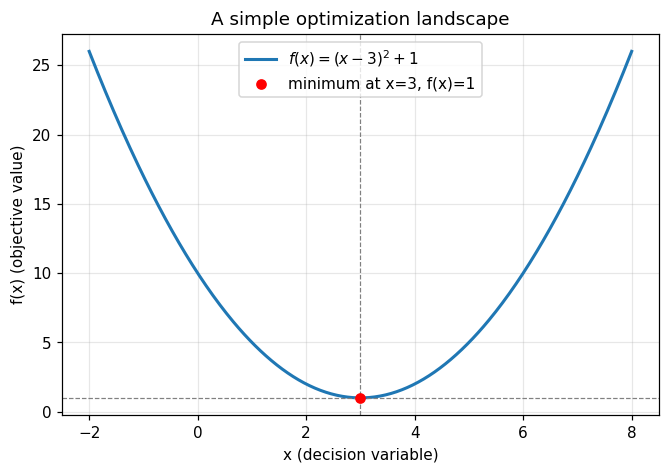

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A simple objective function: f(x) = (x - 3)^2 + 1
# This is a classic "bowl" shape - exactly one minimum, easy to spot.
def f(x):
    return (x - 3)**2 + 1

x = np.linspace(-2, 8, 400)
y = f(x)

# The true minimum, found analytically: f'(x) = 2(x-3) = 0  ->  x = 3
x_min = 3
y_min = f(x_min)

plt.figure(figsize=(7, 4.5))
plt.plot(x, y, linewidth=2, label=r'$f(x) = (x-3)^2 + 1$')
plt.scatter([x_min], [y_min], color='red', zorder=5, label=f'minimum at x={x_min}, f(x)={y_min}')
plt.axhline(y_min, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(x_min, color='gray', linestyle='--', linewidth=0.8)
plt.title('A simple optimization landscape')
plt.xlabel('x (decision variable)')
plt.ylabel('f(x) (objective value)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"The minimum value of f(x) is {y_min} at x = {x_min}")

## 2. Local vs. global optima

- A **local minimum** is a point that's lower than every point *near* it.
- A **global minimum** is the lowest point over the *entire* feasible region.

Picture a blindfolded hiker trying to find the lowest point in a hilly landscape, only able to feel the slope under their feet. They walk downhill, land in a small valley, and — feeling flat ground in every direction — conclude they're done. A much deeper valley might exist just over the next hill, completely invisible to someone who can only feel local slope.

This is one of the central struggles in optimization, and it's exactly why Part III of this curriculum (simulated annealing and other metaheuristics) exists — some algorithms need the ability to occasionally climb back "uphill" to escape a shallow valley in search of a deeper one.

Local minima found (solving g'(x)=0 exactly): [(-0.438, 4.249), (4.015, -2.201)]
Global minimum: (4.015, -2.201)


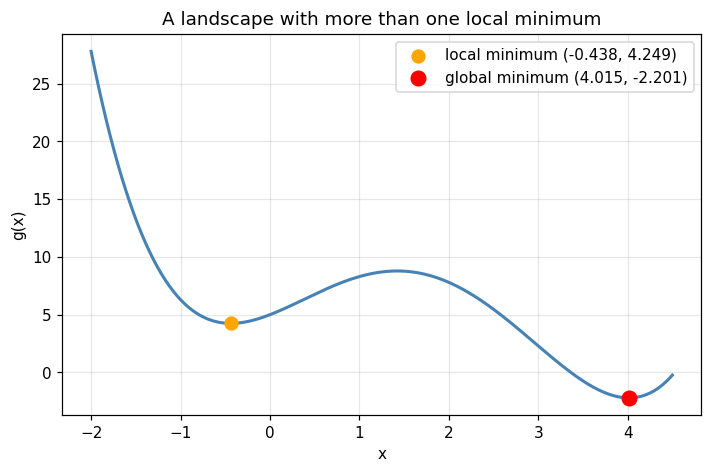

In [2]:
# A function with more than one local minimum.
def g(x):
    return 0.3*x**4 - 2*x**3 + 2*x**2 + 3*x + 5

def g_prime(x):
    return 1.2*x**3 - 6*x**2 + 4*x + 3

def g_double_prime(x):
    return 3.6*x**2 - 12*x + 4

# g is a quartic polynomial, so its critical points (where g'(x) = 0) are
# the roots of a cubic - we can find them exactly instead of guessing with
# a grid search. (For most real functions you can't solve g'(x)=0 by hand -
# that gap is exactly what gradient descent, next notebook, fills: a
# numerical way to hunt for minima without solving equations algebraically.)
raw_roots = np.roots([1.2, -6, 4, 3])            # coefficients of g'(x)
critical_points = raw_roots[np.abs(raw_roots.imag) < 1e-8].real

minima, maxima = [], []
for cx in critical_points:
    point = (round(float(cx), 3), round(float(g(cx)), 3))
    (minima if g_double_prime(cx) > 0 else maxima).append(point)
minima.sort()
global_min = min(minima, key=lambda p: p[1])

x_plot = np.linspace(-2, 4.5, 600)
plt.figure(figsize=(7.5, 4.5))
plt.plot(x_plot, g(x_plot), linewidth=2, color='steelblue')
for cx, cy in minima:
    if (cx, cy) == global_min:
        plt.scatter([cx], [cy], color='red', s=90, zorder=5, label=f'global minimum ({cx}, {cy})')
    else:
        plt.scatter([cx], [cy], color='orange', s=70, zorder=5, label=f'local minimum ({cx}, {cy})')
plt.title('A landscape with more than one local minimum')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Local minima found (solving g'(x)=0 exactly): {minima}")
print(f"Global minimum: {global_min}")

## 3. Maxima vs. minima — the sign-flip trick

Nearly every solver you'll ever use — including `scipy.optimize`, which shows up properly in Chapter 1.3 — is a *minimizer*. If your real problem is "maximize profit" or "maximize accuracy," you don't need new theory: you minimize $-f(x)$ instead. The $x$ that minimizes $-f(x)$ is exactly the $x$ that maximizes $f(x)$. This trick shows up constantly enough that it's worth internalizing now, before it trips you up in code later.

Optimal price: 10.00, maximum profit: 150.00


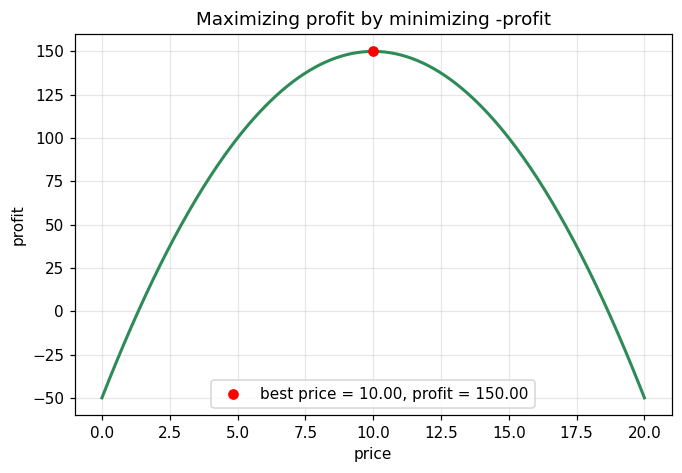

In [3]:
from scipy.optimize import minimize_scalar

# "Maximize profit" example: profit as a function of price.
# profit(price) = -2*price^2 + 40*price - 50   (a classic revenue-minus-cost parabola)
def profit(price):
    return -2*price**2 + 40*price - 50

# scipy.optimize only MINIMIZES - so to maximize profit, we minimize -profit.
result = minimize_scalar(lambda price: -profit(price), bounds=(0, 20), method='bounded')
best_price = result.x
best_profit = profit(best_price)

prices = np.linspace(0, 20, 300)
plt.figure(figsize=(7, 4.5))
plt.plot(prices, profit(prices), linewidth=2, color='seagreen')
plt.scatter([best_price], [best_profit], color='red', zorder=5,
            label=f'best price = {best_price:.2f}, profit = {best_profit:.2f}')
plt.title('Maximizing profit by minimizing -profit')
plt.xlabel('price')
plt.ylabel('profit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal price: {best_price:.2f}, maximum profit: {best_profit:.2f}")

## 4. Convex vs. non-convex

- A **convex set**: pick any two points inside it and draw a straight line between them — the *entire* line stays inside the set. (A filled circle: convex. A crescent moon: not.)
- A **convex function**: pick any two points on the curve and draw a straight line (a *chord*) between them — the curve always lies *on or below* that chord. Visually: a bowl, possibly lopsided, but never a wave.

**Why this matters so much:** for a convex function, *any* local minimum is automatically the *global* minimum. No blindfolded-hiker problem, no getting stuck. This is why so much of classical optimization (Parts I, II, and IV of this curriculum) tries to stay inside convex problems whenever possible.

Our end goal, QUBO, is a *combinatorial* problem over binary variables — it doesn't get the convenient convexity guarantee, which is exactly why Part V needs heuristic solvers like simulated annealing (built in Part III) rather than a single clean formula.

Convex functions: the curve never pokes above its red chord.
Non-convex functions: the curve pokes above the chord somewhere between the two points.


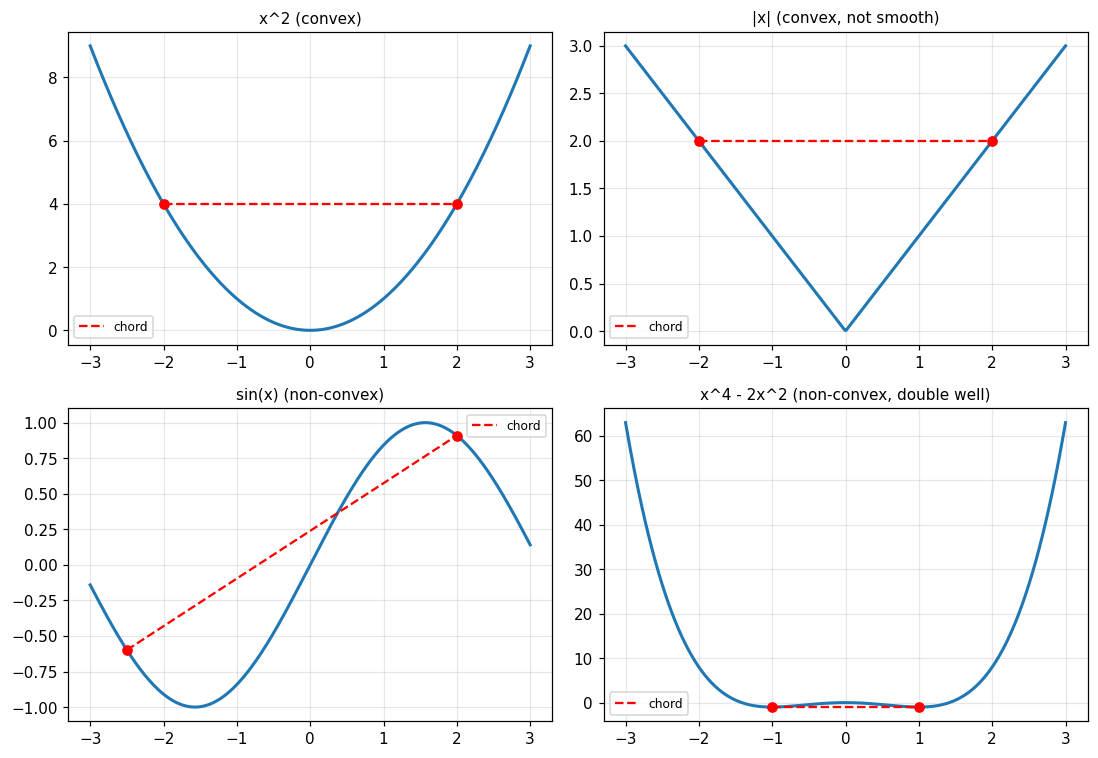

In [4]:
# Let's visually test the "chord on-or-below the curve" rule for convexity.
# Each function comes with a hand-picked pair of x-values to draw the chord
# between, chosen so a non-convex curve visibly pokes ABOVE its chord.

function_specs = {
    'x^2 (convex)': (lambda x: x**2, -2, 2),
    '|x| (convex, not smooth)': (lambda x: np.abs(x), -2, 2),
    'sin(x) (non-convex)': (lambda x: np.sin(x), -2.5, 2.0),
    'x^4 - 2x^2 (non-convex, double well)': (lambda x: x**4 - 2*x**2, -1, 1),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
x_plot = np.linspace(-3, 3, 400)

for ax, (label, (func, x1, x2)) in zip(axes.flat, function_specs.items()):
    y_plot = func(x_plot)
    ax.plot(x_plot, y_plot, linewidth=2)

    y1, y2 = func(x1), func(x2)
    ax.plot([x1, x2], [y1, y2], color='red', linestyle='--', linewidth=1.5, label='chord')
    ax.scatter([x1, x2], [y1, y2], color='red', zorder=5)

    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Convex functions: the curve never pokes above its red chord.")
print("Non-convex functions: the curve pokes above the chord somewhere between the two points.")

## 5. Why this matters for where we're headed

Quick recap of the thread: every optimization problem — from a simple parabola to QUBO — is built from the same four pieces (decision variables, objective, constraints, feasible region). Convexity is the difference between "any local minimum is automatically the best one" and "you might get stuck, and need a smarter search strategy." QUBO problems are non-convex and combinatorial, which is precisely why Part III (metaheuristics) and Part V (QUBO itself) exist — they're the toolkit for landscapes where convexity doesn't save us.

**Next, in Chapter 1.2:** we'll build the tool for *searching* these landscapes — gradient descent, derived and coded from scratch.

## Exercise 1.1

For each function below, state whether it is **convex**, **concave**, or **neither**, and briefly explain why (a one-line reason is enough — think about the chord test, or whether it has a single "bowl" shape).

1. $f(x) = x^2$
2. $f(x) = -x^2$
3. $f(x) = x^3$ (consider all of $\mathbb{R}$)
4. $f(x) = |x|$
5. $f(x) = \sin(x)$ (consider all of $\mathbb{R}$)
6. $f(x) = x^4 - x^2$

Try to answer before scrolling to the solution below — that's where the actual learning happens. The code cell right after this one just plots all six, if you want a visual hint first.

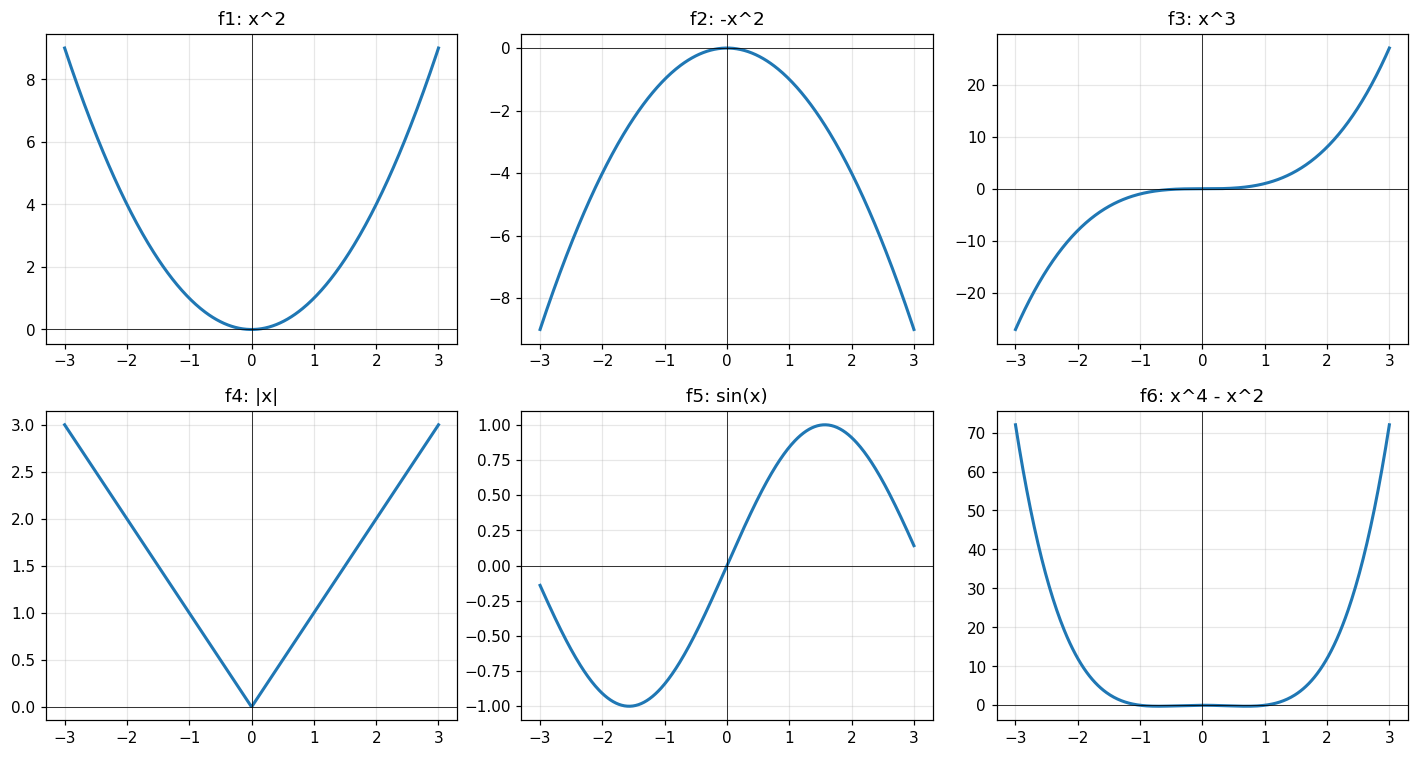

In [5]:
# Use this cell to explore the 6 functions before checking the solution below.
# Try judging each one visually: does it look like a single bowl (convex), an
# upside-down bowl (concave), or something else (neither)?

exercise_functions = {
    'f1: x^2': lambda x: x**2,
    'f2: -x^2': lambda x: -x**2,
    'f3: x^3': lambda x: x**3,
    'f4: |x|': lambda x: np.abs(x),
    'f5: sin(x)': lambda x: np.sin(x),
    'f6: x^4 - x^2': lambda x: x**4 - x**2,
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
x_plot = np.linspace(-3, 3, 400)

for ax, (label, func) in zip(axes.flat, exercise_functions.items()):
    ax.plot(x_plot, func(x_plot), linewidth=2)
    ax.set_title(label)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## Solution — Exercise 1.1

1. **$x^2$ — Convex.** The classic bowl; second derivative $f''(x) = 2 \ge 0$ everywhere.
2. **$-x^2$ — Concave.** The upside-down bowl; $f''(x) = -2 \le 0$ everywhere. (Concave is just convex with the sign flipped — the same max/min trick from Section 3.)
3. **$x^3$ — Neither.** $f''(x) = 6x$, negative for $x<0$ and positive for $x>0$ — concave on one side, convex on the other, with an inflection point at $x=0$. Over all of $\mathbb{R}$, it's neither.
4. **$|x|$ — Convex.** Not smooth at $x=0$ (no derivative there), but still convex — convexity only requires that every chord stays on or above the curve, not that the curve be smooth.
5. **$\sin(x)$ — Neither.** It oscillates between concave and convex regions forever; no single chord test works globally.
6. **$x^4 - x^2$ — Neither.** This is a *double well*: two local minima separated by a local maximum at $x=0$. By symmetry these two minima happen to tie — but tilt the function slightly (exactly like Section 2's $g(x)$) and one becomes strictly better than the other. This is the classic shape behind non-convex optimization: multiple valleys, with no guarantee the one you land in is the best one.

In [6]:
# Verify the classifications numerically rather than just asserting them -
# sample the second derivative at several points and check its sign.
# (Convex needs f''(x) >= 0 everywhere; concave needs f''(x) <= 0 everywhere.)

def numerical_second_derivative(func, x, h=1e-4):
    return (func(x + h) - 2*func(x) + func(x - h)) / h**2

verify_functions = {
    'x^2': lambda x: x**2,
    '-x^2': lambda x: -x**2,
    'x^3': lambda x: x**3,
    '|x|': lambda x: np.abs(x),
    'sin(x)': lambda x: np.sin(x),
    'x^4 - x^2': lambda x: x**4 - x**2,
}

sample_points = np.linspace(-2.5, 2.5, 101)  # dense enough to catch narrow curvature-sign changes
sample_points = sample_points[np.abs(sample_points) > 1e-3]  # skip x=0, where |x| has a kink

print(f"{'function':<12} {'verdict'}")
print("-" * 45)
for name, func in verify_functions.items():
    second_derivs = [numerical_second_derivative(func, xi) for xi in sample_points]
    signs = set(np.sign(np.round(sd, 3)) for sd in second_derivs)
    if signs <= {1.0, 0.0}:
        verdict = "convex everywhere sampled (f'' >= 0)"
    elif signs <= {-1.0, 0.0}:
        verdict = "concave everywhere sampled (f'' <= 0)"
    else:
        verdict = "mixed sign - neither convex nor concave"
    print(f"{name:<12} {verdict}")

function     verdict
---------------------------------------------
x^2          convex everywhere sampled (f'' >= 0)
-x^2         concave everywhere sampled (f'' <= 0)
x^3          mixed sign - neither convex nor concave
|x|          convex everywhere sampled (f'' >= 0)
sin(x)       mixed sign - neither convex nor concave
x^4 - x^2    mixed sign - neither convex nor concave


## Section 1 complete ✓

You now have the vocabulary for the rest of this curriculum: decision variables, objective functions, constraints, feasible regions, local vs. global optima, the maximize↔minimize trick, and convexity.

**Next: Chapter 1.2** — Calculus Refresher & Gradient Descent From Scratch, where we build the algorithm that actually *searches* these landscapes.